# DENSE AE TRAINING

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import h5py

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

2026-06-23 09:54:25.999624: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 09:54:26.085352: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
BACKGROUND_FILE = "../data/datasets/dense/background_dense_dataset.h5"

with h5py.File(BACKGROUND_FILE, 'r') as f:
    X_train = f['X_train'][:].astype(np.float32)
    X_val   = f['X_val'][:].astype(np.float32)
    X_test  = f['X_test'][:].astype(np.float32)
print(f'{"X_train":<10}: {X_train.shape}')
print(f'{"X_val":<10}: {X_val.shape}')
print(f'{"X_test":<10}: {X_test.shape}')

X_train   : (8609225, 57)
X_val     : (2152307, 57)
X_test    : (2690383, 57)


In [3]:
DENSE_MODELS_DIR = "../models/dense_AE"
os.makedirs(DENSE_MODELS_DIR, exist_ok=True)

MODEL_NAME = "dense_ae_10"

SAVE_MODEL_PATH = os.path.join(DENSE_MODELS_DIR, f"{MODEL_NAME}.keras")

In [4]:
N_OBJ  = 19
PT_COLS  = [i*3 for i in range(N_OBJ)]

PT_STD = X_train[:, PT_COLS].std() + 1e-8

In [5]:
# Custom loss
W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}

def masked_trigger_loss(y_true, y_pred):
    # (B,57) -> (B,19,3)
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    # object exists iff pT != 0
    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)

    # pT
    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (PT_STD**2)

    # eta
    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    # phi
    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = W_CURR["pt"] * pt_loss + W_CURR["eta"] * eta_loss + W_CURR["phi"] * phi_loss
    total *= mask

    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)
    return tf.reduce_mean(tf.reduce_sum(total, axis=[1, 2]) / n_present)

In [6]:
'''
def masked_components(y_true, y_pred, pt_std, weights):
    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = weights['pt'] * pt_loss + weights['eta'] * eta_loss + weights['phi'] * phi_loss
    total = total * mask

    evt_loss = tf.reduce_sum(total, axis=[1, 2]) / n_present
    return evt_loss

def make_focal_tail_loss(pt_std, weights, gamma=2.0, w_min=0.25, w_max=4.0):
    def focal_tail_loss(y_true, y_pred):
        evt_loss = masked_components(y_true, y_pred, pt_std=pt_std, weights=weights)
        evt_mean = tf.stop_gradient(tf.reduce_mean(evt_loss))
        focal_w = tf.pow(evt_loss / (evt_mean + 1e-8), gamma)
        focal_w = tf.clip_by_value(focal_w, w_min, w_max)
        return tf.reduce_mean(focal_w * evt_loss)
    return focal_tail_loss
'''

"\ndef masked_components(y_true, y_pred, pt_std, weights):\n    y_true = tf.reshape(y_true, (-1, 19, 3))\n    y_pred = tf.reshape(y_pred, (-1, 19, 3))\n\n    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)\n    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)\n\n    pt_true = y_true[:, :, 0:1]\n    pt_pred = y_pred[:, :, 0:1]\n    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)\n\n    eta_true = y_true[:, :, 1:2]\n    eta_pred = y_pred[:, :, 1:2]\n    eta_loss = tf.square((eta_true - eta_pred) / 3.0)\n\n    phi_true = y_true[:, :, 2:3]\n    phi_pred = y_pred[:, :, 2:3]\n    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))\n    phi_loss = tf.square(dphi)\n\n    total = weights['pt'] * pt_loss + weights['eta'] * eta_loss + weights['phi'] * phi_loss\n    total = total * mask\n\n    evt_loss = tf.reduce_sum(total, axis=[1, 2]) / n_present\n    return evt_loss\n\ndef make_focal_tail_loss(pt_std, weights, gamma=2.0, w_min=0.25, w_

In [7]:
# Model

def build_dense_ae(input_dim=57, latent_dim=16, name="dense_ae"):
    inp = keras.Input(shape=(input_dim,), name="input")

    # Encoder
    x = layers.BatchNormalization()(inp)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(32, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    z = layers.Dense(latent_dim, name="latent")(x)

    # Decoder
    x = layers.Dense(32, use_bias=False)(z)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dense(48, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    out = layers.Dense(input_dim)(x)

    return Model(inp, out, name=name)

dense_ae = build_dense_ae()
dense_ae.summary()

I0000 00:00:1782201325.781188   49823 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "dense_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 57)             │           228 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         2,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 48)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 57)             │         2,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,509 (41.05 KB)

 Trainable params: 10,075 (39.36 KB)

 Non-trainable params: 434 (1.70 KB)

In [8]:
# Train

EPOCHS = 100
BATCH_SIZE = 1024
LR = 1e-3

dense_ae.compile(optimizer=keras.optimizers.Adam(LR), loss=masked_trigger_loss)

cb = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    keras.callbacks.ModelCheckpoint(SAVE_MODEL_PATH, save_best_only=True),
]

history_dae = dense_ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    verbose=1,
)

Epoch 1/100


2026-06-23 09:55:38.944947: I external/local_xla/xla/service/service.cc:163] XLA service 0x1ba41df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-23 09:55:38.944981: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-06-23 09:55:39.034095: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-23 09:55:39.576902: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
I0000 00:00:1782201341.704368   49960 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8408/8408 - 47s - 6ms/step - loss: 5.6899 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 2/100
8408/8408 - 35s - 4ms/step - loss: 0.6123 - val_loss: 0.2909 - learning_rate: 0.0010
Epoch 3/100
8408/8408 - 36s - 4ms/step - loss: 0.5023 - val_loss: 0.2270 - learning_rate: 0.0010
Epoch 4/100
8408/8408 - 36s - 4ms/step - loss: 0.4126 - val_loss: 0.1848 - learning_rate: 0.0010
Epoch 5/100
8408/8408 - 36s - 4ms/step - loss: 0.3684 - val_loss: 0.1770 - learning_rate: 0.0010
Epoch 6/100
8408/8408 - 35s - 4ms/step - loss: 0.3355 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 7/100
8408/8408 - 35s - 4ms/step - loss: 0.3024 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 8/100
8408/8408 - 35s - 4ms/step - loss: 0.2865 - val_loss: 0.1379 - learning_rate: 0.0010
Epoch 9/100
8408/8408 - 35s - 4ms/step - loss: 0.2753 - val_loss: 0.1311 - learning_rate: 0.0010
Epoch 10/100
8408/8408 - 36s - 4ms/step - loss: 0.2664 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 11/100
8408/8408 - 36s - 4ms/step -

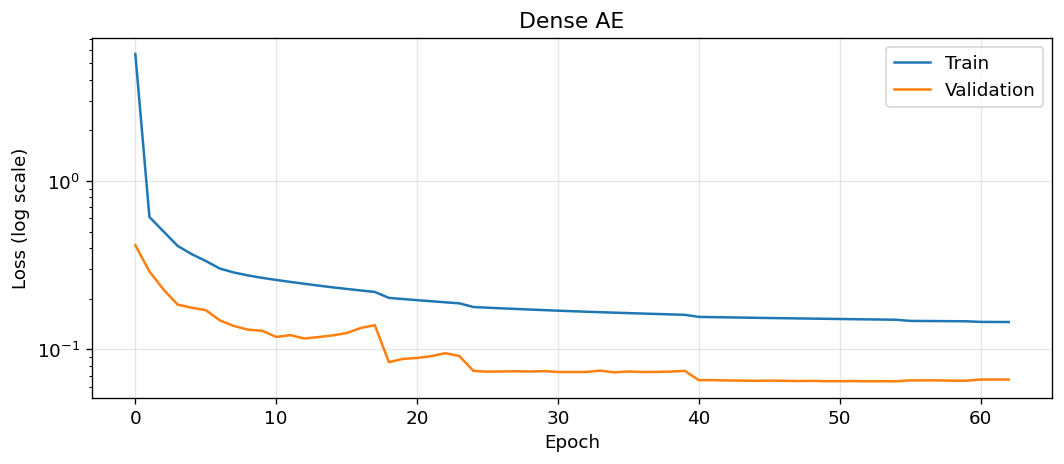

In [9]:
def plot_history(history, title="Training history"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(history.history["loss"], label="Train")
    ax.semilogy(history.history["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_dae, "Dense AE")

In [10]:
def compute_masked_components_arrays(model, X, batch_size=8192):
    y_true = tf.convert_to_tensor(X, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(model.predict(X, batch_size=batch_size, verbose=0), dtype=tf.float32)

    y_true = tf.reshape(y_true, (-1, 19, 3))
    y_pred = tf.reshape(y_pred, (-1, 19, 3))

    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (PT_STD**2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    pt_evt = tf.reduce_sum(pt_loss * mask, axis=[1, 2]) / n_present
    eta_evt = tf.reduce_sum(eta_loss * mask, axis=[1, 2]) / n_present
    phi_evt = tf.reduce_sum(phi_loss * mask, axis=[1, 2]) / n_present

    return {
        "pt_evt": pt_evt.numpy(),
        "eta_evt": eta_evt.numpy(),
        "phi_evt": phi_evt.numpy()
    }

def summarize_components(comp, weights):
    pt_m = float(np.mean(comp["pt_evt"]))
    eta_m = float(np.mean(comp["eta_evt"]))
    phi_m = float(np.mean(comp["phi_evt"]))

    pt_w = weights["pt"] * pt_m
    eta_w = weights["eta"] * eta_m
    phi_w = weights["phi"] * phi_m
    tot_w = pt_w + eta_w + phi_w

    return {
        "unweighted_mean": {"pt": pt_m, "eta": eta_m, "phi": phi_m},
        "weighted_mean": {"pt": pt_w, "eta": eta_w, "phi": phi_w, "total": tot_w},
        "weighted_fraction": {
            "pt": pt_w / (tot_w + 1e-12),
            "eta": eta_w / (tot_w + 1e-12),
            "phi": phi_w / (tot_w + 1e-12)
        },
    }

def print_summary(split_name, summary):
    print(f"\n=== {split_name} ===")
    print("Unweighted means:")
    print(
        f"  pt={summary['unweighted_mean']['pt']:.6f}, "
        f"eta={summary['unweighted_mean']['eta']:.6f}, "
        f"phi={summary['unweighted_mean']['phi']:.6f}"
    )
    print("Weighted means:")
    print(
        f"  pt={summary['weighted_mean']['pt']:.6f}, "
        f"eta={summary['weighted_mean']['eta']:.6f}, "
        f"phi={summary['weighted_mean']['phi']:.6f}, "
        f"total={summary['weighted_mean']['total']:.6f}"
    )
    print("Weighted fractions:")
    print(
        f"  pt={summary['weighted_fraction']['pt']:.3f}, "
        f"eta={summary['weighted_fraction']['eta']:.3f}, "
        f"phi={summary['weighted_fraction']['phi']:.3f}"
    )

comp_train = compute_masked_components_arrays(dense_ae, X_train)
comp_val = compute_masked_components_arrays(dense_ae, X_val)

summary_train = summarize_components(comp_train, W_CURR)
summary_val = summarize_components(comp_val, W_CURR)

print_summary("TRAIN", summary_train)
print_summary("VAL", summary_val)


=== TRAIN ===
Unweighted means:
  pt=0.000525, eta=0.015868, phi=0.208847
Weighted means:
  pt=0.000525, eta=0.015868, phi=0.104423, total=0.120817
Weighted fractions:
  pt=0.004, eta=0.131, phi=0.864

=== VAL ===
Unweighted means:
  pt=0.000527, eta=0.015817, phi=0.208925
Weighted means:
  pt=0.000527, eta=0.015817, phi=0.104463, total=0.120807
Weighted fractions:
  pt=0.004, eta=0.131, phi=0.865
